In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import numpy as np
import glob
import shutil
import xarray as xr
from helita.sim import bifrost as br
from astropy.time import Time
import museval
from museval.utils import get_response, find_response, aia_synthesis
from muse.synthesis.synthesis import transform_resp_units
import matplotlib.colors as colors
import matplotlib.pyplot as plt


In [2]:
# os.environ['RESPONSE'] = '/Users/souvikb/MUSE_outputs/response/'
os.environ['VDEM_path'] = '/Users/souvikb/MUSE_outputs/vdems/'
qs_vdem = xr.open_zarr(os.path.join(os.environ['VDEM_path'], 'muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr'))
os.environ['RESPONSE'] = '/Users/souvikb/MUSE_outputs/response/new_response/'
date = '2015-08-17T00:00:00'
date_sensitive = True
units = 'DN'
if date_sensitive:
    date = Time(date,format='isot',scale='utc') # astropy time object
    print(f' Date Sensitive AIA {units} Response from {date.strftime("%b %y")}')
    aia_resp = get_response(qs_vdem, date = date, save_response = True)
#     aia_resp = get_response(
#     qs_vdem,
#     date=date,
#     uzmin=float(qs_vdem.vdop.min()),
#     uzmax=float(qs_vdem.vdop.max()) + 10.0,
#     uzstep=10.0,
#     lgtgmin=float(qs_vdem.logT.min()),
#     lgtgmax=float(qs_vdem.logT.max()) + 0.1,
#     lgtgstep=0.1,
# )

else:
    print(f' Generic AIA {units} Response')
    aia_resp = get_response()

 Date Sensitive AIA DN Response from Aug 15
2026-02-25 15:54:30.696 | INFO     | museval.utils:find_response:73 - *** Nearest response function is 24 months from obs_date 
2026-02-25 15:54:30.696 | INFO     | museval.utils:get_response:192 - *** Constructing line list using pressure = 3.0e+15, abundance sun_photospheric_2021_asplund
 ChiantiPy version 0.15.2 
 found PyQt5 widgets
 using PyQt5 widgets
 elapsed seconds =      296.000
2026-02-25 15:59:33.918 | INFO     | museval.utils:get_response:203 - *** Correction table taken from local JSOC installation
2026-02-25 15:59:34.118 | INFO     | museval.utils:get_response:214 - *** Computing DN response function for 94.0 Angstrom date Aug2015
2026-02-25 16:00:18.796 | INFO     | museval.utils:get_response:214 - *** Computing DN response function for 131.0 Angstrom date Aug2015
2026-02-25 16:01:02.689 | INFO     | museval.utils:get_response:214 - *** Computing DN response function for 171.0 Angstrom date Aug2015
2026-02-25 16:01:46.528 | IN

In [4]:
print(qs_vdem.vdop.size, float(qs_vdem.vdop.min()), float(qs_vdem.vdop.max()))
print(aia_resp.vdop.size, float(aia_resp.vdop.min()), float(aia_resp.vdop.max()))


18 -70.0 100.0
18 -70.0 100.0


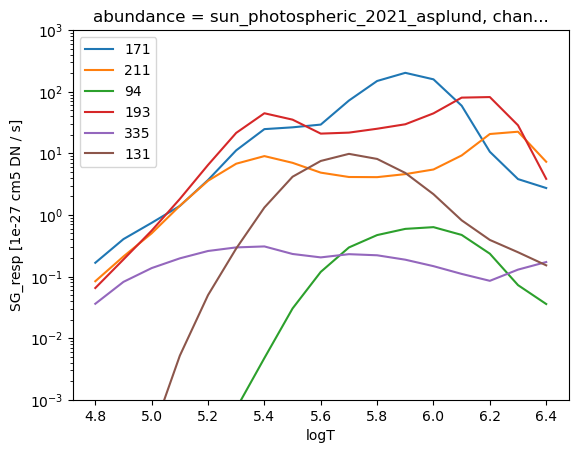

In [4]:
aia_resp.SG_resp.sel(channel=171,vdop=0).plot(label='171')
aia_resp.SG_resp.sel(channel=211,vdop=0).plot(label='211')
aia_resp.SG_resp.sel(channel=94,vdop=0).plot(label='94')
aia_resp.SG_resp.sel(channel=193,vdop=0).plot(label='193')
aia_resp.SG_resp.sel(channel=335,vdop=0).plot(label='335')
aia_resp.SG_resp.sel(channel=131,vdop=0).plot(yscale='log',label='131')
plt.ylim(1e-3,1e3)
# plt.xlim(4.4, 7.0)
plt.legend()


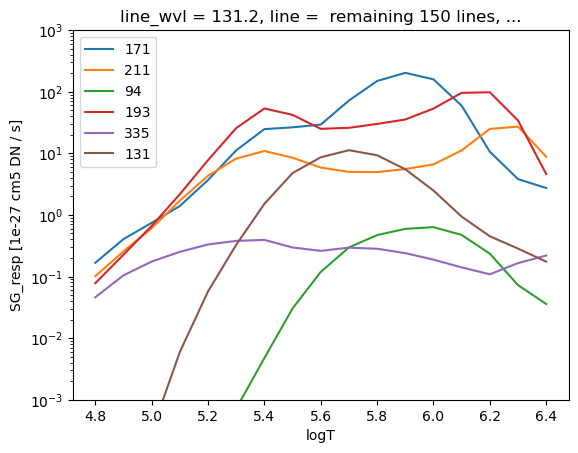

In [5]:
aia_resp.SG_resp.sel(channel=171,vdop=0).plot(label='171')
aia_resp.SG_resp.sel(channel=211,vdop=0).plot(label='211')
aia_resp.SG_resp.sel(channel=94,vdop=0).plot(label='94')
aia_resp.SG_resp.sel(channel=193,vdop=0).plot(label='193')
aia_resp.SG_resp.sel(channel=335,vdop=0).plot(label='335')
aia_resp.SG_resp.sel(channel=131,vdop=0).plot(yscale='log',label='131')
plt.ylim(1e-3,1e3)
# plt.xlim(4.4, 7.0)
plt.legend()


### Quick Sanity Check for synthesis of the AIA intensities using the response function and the VDEM.

In [6]:
data1 = np.load('/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/combined_aia_observations.npz')
data1.files
all_171 = data1['a171_all']
all_193 = data1['a193_all']
all_131 = data1['a131_all']
all_211 = data1['a211_all']

Text(0.5, 0.95, 'All QS datasets')

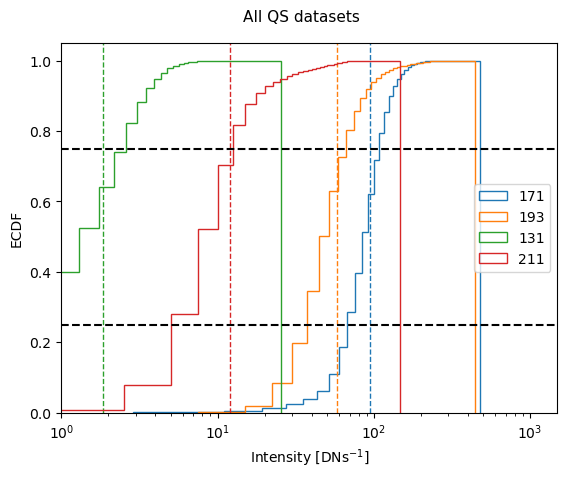

In [7]:
num_bins = 60
fig, ax = plt.subplots()
bins = np.linspace(all_171.min(), all_171.max(), num_bins)
hist, bin_edges = np.histogram(all_171, bins=bins)
ax.hist(all_171, bins=bins, label='171', histtype='step',cumulative=True, weights=np.ones(len(all_171)) / len(all_171))
ax.axvline(x=np.mean(all_171),color='#1f77b4',lw=1,ls='--')
# ax.yaxis.set_major_formatter(PercentFormatter(1))

bins = np.linspace(all_193.min(), all_193.max(), num_bins)
hist, bin_edges = np.histogram(all_193, bins=bins)
ax.hist(all_193, bins=bins, label='193', histtype='step', cumulative=True,weights=np.ones(len(all_193)) / len(all_193))
ax.axvline(x=np.mean(all_193),color='#ff7f0e',lw=1,ls='--')
# ax.yaxis.set_major_formatter(PercentFormatter(1))

bins = np.linspace(all_131.min(), all_131.max(), num_bins)
hist, bin_edges = np.histogram(all_131, bins=bins)
ax.hist(all_131.ravel(), bins=bins, label='131', histtype='step',cumulative=True,weights=np.ones(len(all_131)) / len(all_131))
ax.axvline(x=np.mean(all_131),color='#2ca02c',lw=1,ls='--')
# ax.yaxis.set_major_formatter(PercentFormatter(1))

bins = np.linspace(all_211.min(), all_211.max(), num_bins)
hist, bin_edges = np.histogram(all_211, bins=bins)
ax.hist(all_211, bins=bins, label='211', histtype='step',cumulative=True,weights=np.ones(len(all_211)) / len(all_211))
ax.axvline(x=np.mean(all_211),color='#d62728',lw=1,ls='--')
ax.set_xlabel(r'Intensity [DNs$^{-1}$]')
# ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('ECDF')
ax.set_xlim([1,1500])
# ax.set_ylim([0,0.2])
ax.legend()
ax.axhline(y=0.25,color='black',ls='--')
ax.axhline(y=0.75,color='black',ls='--')
fig.suptitle('All QS datasets',y=0.95,size=11)

In [8]:
vdem_file = os.path.join(os.environ['VDEM_path'], 'muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr')
work_dir = '/Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/'
muse_AIA_QS = aia_synthesis(aia_resp, work_dir, vdem_file, swap_dims = False)

2026-02-25 16:04:45.254 | INFO     | museval.utils:aia_synthesis:403 - *** Work directory is /Users/souvikb/MUSE_outputs/EIS_IRIS_QS_obs/QS_datasets/
2026-02-25 16:04:45.255 | INFO     | museval.utils:aia_synthesis:410 - *** Loading /Users/souvikb/MUSE_outputs/vdems/muse_vdem_qs_en024031_los2_JMS_fixedvdop_2May2025_010.zarr into vdem


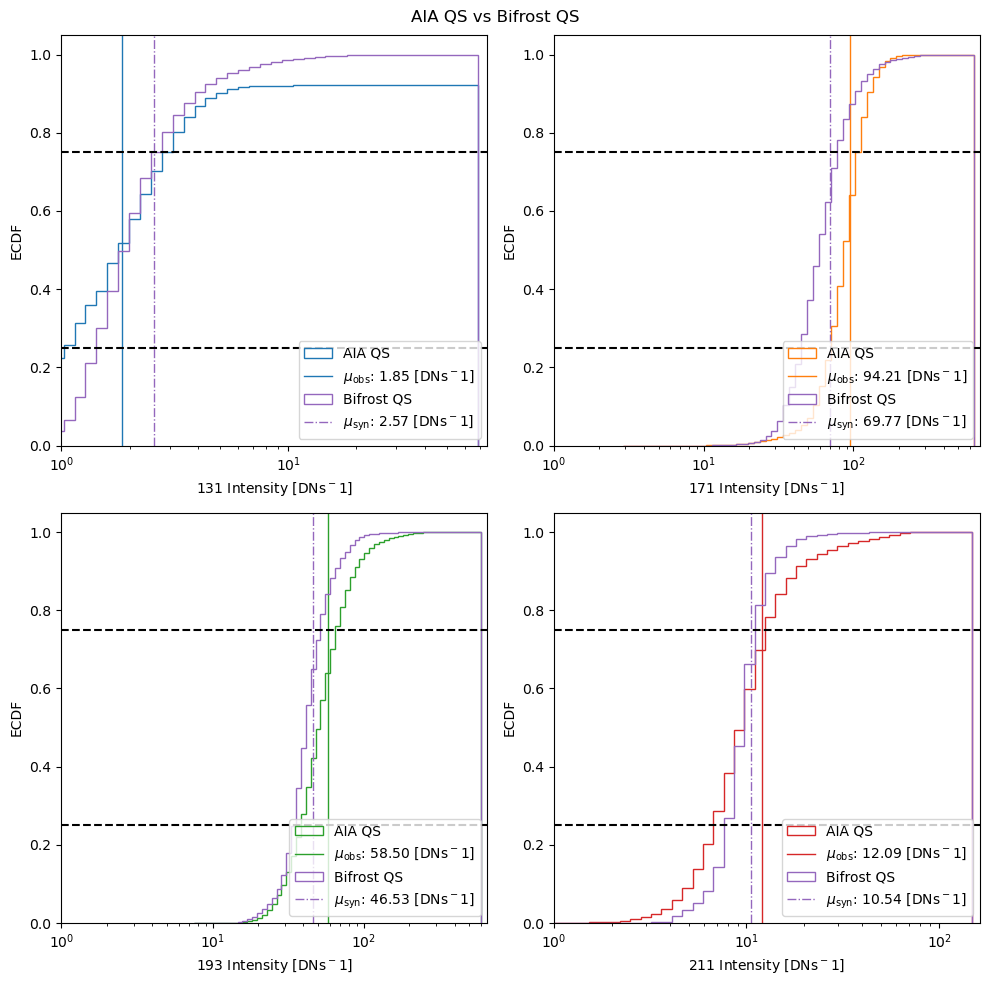

In [11]:
region = 'QS'
fig, ax = plt.subplots(2,2,figsize=(10,10))
colors_channel = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
channels = [131,171,193,211]
MHD_code ='Bifrost'
snapname = 'QS'
for i,channel in enumerate(channels):
    # exp_time = AIA_DATA[channel].exposure_time
    data = np.ravel(data1['a'+str(channel)+'_all'])
    bf = muse_AIA_QS.flux.sel(channel=channel).to_numpy()
    combined = np.concatenate([data, bf.ravel()])
    min_val = max(combined.min(), 1e-1)  # avoiding log(0). This can be nasty otherwise
    max_val = combined.max()
    bins_new = np.logspace(np.log10(min_val), np.log10(max_val), num_bins)
    # bins_new = np.linspace(combined.min(), combined.max(), 60)
    hist, bin_edges = np.histogram(data, bins=bins_new)
    ax[i//2][i%2].hist(data, bins=bins_new, label=f'AIA {region}',cumulative=True, histtype='step',
                        weights=np.ones(len(data)) / len(data), color=colors_channel[i])
    ax[i//2][i%2].axvline(x=np.mean(data),color=colors_channel[i],lw=1,ls='-',
                            label=f'$\mu_{{\mathrm{{obs}}}}$: {np.mean(data):.2f} [DNs$^{-1}$]')

    ax[i//2][i%2].hist(bf.ravel(), bins=bins_new, label=f'{MHD_code} {snapname}',cumulative=True, histtype='step',
                        weights=np.ones(len(bf.ravel())) / len(bf.ravel()),color='tab:purple',ls='-.',lw=2.)
    ax[i//2][i%2].axvline(x=np.mean(bf.ravel()),color='tab:purple',lw=1,ls='-.',label=f'$\mu_{{\mathrm{{syn}}}}$: {np.mean(bf.ravel()):.2f} [DNs$^{-1}$]')
    ax[i//2][i%2].set_xlabel(fr'{channel} Intensity [DNs$^{-1}$]')
    ax[i//2][i%2].set_xlim([1, max_val * 1.1])
    # if channel == 171:
    #     ax[i//2][i%2].set_xlim([1, 1e4])
    # elif channel == 193:
    #     ax[i//2][i%2].set_xlim([1, 1e4])
    # elif channel == 211:
    #     ax[i//2][i%2].set_xlim([1, 3e3])
    # elif channel == 131:
    #     ax[i//2][i%2].set_xlim([1, 1e3])
    ax[i//2][i%2].set_xscale('log')
    ax[i//2][i%2].set_ylabel('ECDF')
    ax[i//2][i%2].legend(loc='lower right')
    ax[i//2][i%2].axhline(y=0.25,color='black',ls='--')
    ax[i//2][i%2].axhline(y=0.75,color='black',ls='--')

title = f"AIA {region} vs {MHD_code} {snapname}"
fig.suptitle(title,y=0.98)
plt.tight_layout()
# plt.savefig()

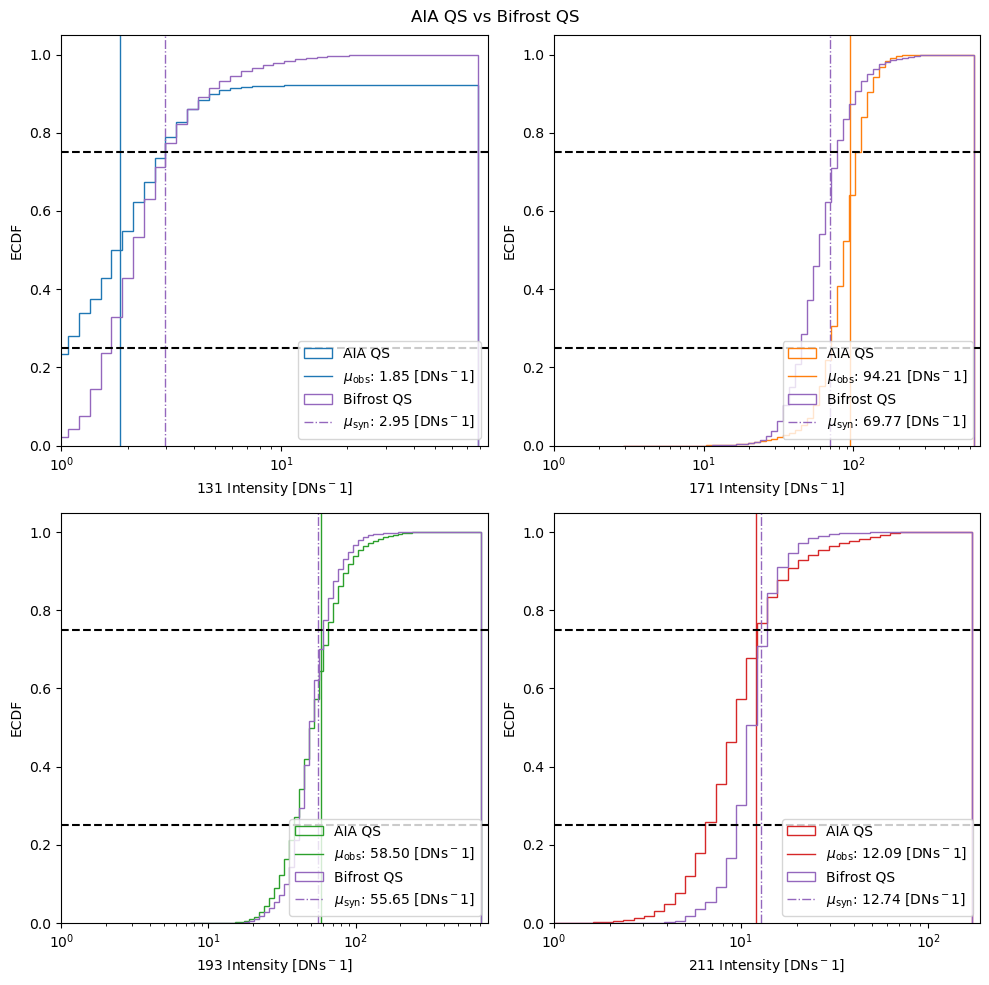

In [9]:
region = 'QS'
fig, ax = plt.subplots(2,2,figsize=(10,10))
colors_channel = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
channels = [131,171,193,211]
MHD_code ='Bifrost'
snapname = 'QS'
for i,channel in enumerate(channels):
    # exp_time = AIA_DATA[channel].exposure_time
    data = np.ravel(data1['a'+str(channel)+'_all'])
    bf = muse_AIA_QS.flux.sel(channel=channel).to_numpy()
    combined = np.concatenate([data, bf.ravel()])
    min_val = max(combined.min(), 1e-1)  # avoiding log(0). This can be nasty otherwise
    max_val = combined.max()
    bins_new = np.logspace(np.log10(min_val), np.log10(max_val), num_bins)
    # bins_new = np.linspace(combined.min(), combined.max(), 60)
    hist, bin_edges = np.histogram(data, bins=bins_new)
    ax[i//2][i%2].hist(data, bins=bins_new, label=f'AIA {region}',cumulative=True, histtype='step',
                        weights=np.ones(len(data)) / len(data), color=colors_channel[i])
    ax[i//2][i%2].axvline(x=np.mean(data),color=colors_channel[i],lw=1,ls='-',
                            label=f'$\mu_{{\mathrm{{obs}}}}$: {np.mean(data):.2f} [DNs$^{-1}$]')

    ax[i//2][i%2].hist(bf.ravel(), bins=bins_new, label=f'{MHD_code} {snapname}',cumulative=True, histtype='step',
                        weights=np.ones(len(bf.ravel())) / len(bf.ravel()),color='tab:purple',ls='-.',lw=2.)
    ax[i//2][i%2].axvline(x=np.mean(bf.ravel()),color='tab:purple',lw=1,ls='-.',label=f'$\mu_{{\mathrm{{syn}}}}$: {np.mean(bf.ravel()):.2f} [DNs$^{-1}$]')
    ax[i//2][i%2].set_xlabel(fr'{channel} Intensity [DNs$^{-1}$]')
    ax[i//2][i%2].set_xlim([1, max_val * 1.1])
    # if channel == 171:
    #     ax[i//2][i%2].set_xlim([1, 1e4])
    # elif channel == 193:
    #     ax[i//2][i%2].set_xlim([1, 1e4])
    # elif channel == 211:
    #     ax[i//2][i%2].set_xlim([1, 3e3])
    # elif channel == 131:
    #     ax[i//2][i%2].set_xlim([1, 1e3])
    ax[i//2][i%2].set_xscale('log')
    ax[i//2][i%2].set_ylabel('ECDF')
    ax[i//2][i%2].legend(loc='lower right')
    ax[i//2][i%2].axhline(y=0.25,color='black',ls='--')
    ax[i//2][i%2].axhline(y=0.75,color='black',ls='--')

title = f"AIA {region} vs {MHD_code} {snapname}"
fig.suptitle(title,y=0.98)
plt.tight_layout()
# plt.savefig()